<a href="https://colab.research.google.com/github/RafiFirnanda/Skripsi-Analisis-Determinan-Kasus-Korupsi/blob/main/FinalCodeSkripsiRafi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================================
# --- CELL 1: SETUP & LIBRARY ---
# =========================================================================
try:
    import shap
except ImportError:
    import os
    os.system('pip install shap')
    import shap

try:
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.combine import SMOTETomek
except ImportError:
    import os
    os.system('pip install imbalanced-learn')
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.combine import SMOTETomek

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau, rankdata

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    sns.set_theme(style="whitegrid")

print("✅ CELL 1: Library & Konfigurasi Berhasil Di-load.")

✅ CELL 1: Library & Konfigurasi Berhasil Di-load.


In [ ]:
# =========================================================================
# --- CELL 2: LOAD & CLEANING DATA ---
# =========================================================================
try:
    with open('ekstraksi_dataset.csv', 'r', encoding='utf-8') as f:
        lines = [line.replace(',,', ',') for line in f]
    df = pd.read_csv(io.StringIO(''.join(lines)))
    print(f"Data Awal Loaded: {len(df)} baris")
except FileNotFoundError:
    print("❌ File 'ekstraksi_dataset.csv' tidak ditemukan. Menggunakan DataFrame kosong.")
    df = pd.DataFrame()

if not df.empty:
    df = df.rename(columns={'tuntutan_penjara': 'vonis_bulan'})

    # Cleaning format angka finansial
    cols_uang = ['nominal_uang', 'uang_pengganti']
    for col in cols_uang:
        df[col] = df[col].astype(str).str.replace('.', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df['vonis_bulan'] = pd.to_numeric(df['vonis_bulan'], errors='coerce')
    df['subsider_penjara'] = pd.to_numeric(df['subsider_penjara'], errors='coerce').fillna(0)

    # Filter baris tidak valid & penyetaraan jabatan
    df = df.dropna(subset=['jabatan_terdakwa', 'vonis_bulan'])
    df['jabatan_terdakwa'] = df['jabatan_terdakwa'].replace('Wiraswasta', 'Swasta')

    print("✅ CELL 2: Data Cleaning Selesai.")

Data Awal Loaded: 98 baris
✅ CELL 2: Data Cleaning Selesai.


✅ CELL 3: Feature Engineering Selesai. Dimension X: (96, 9)


/tmp/ipykernel_1148/1348010549.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


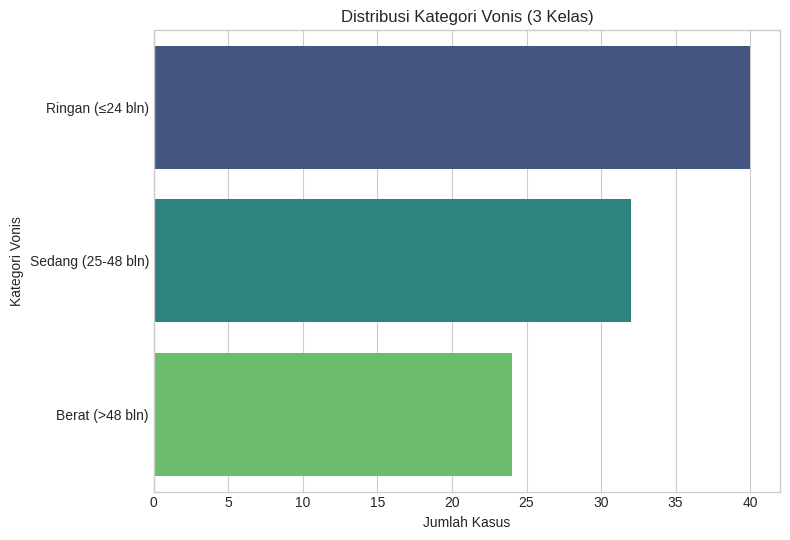

In [ ]:
# =========================================================================
# --- CELL 3: FEATURE ENGINEERING (3 KELAS) & VISUALISASI ---
# =========================================================================
def kategorisasi_vonis(bulan):
    if bulan <= 24:
        return 0  # Ringan
    elif bulan <= 48:
        return 1  # Sedang
    else:
        return 2  # Berat

df['status_hukuman'] = df['vonis_bulan'].apply(kategorisasi_vonis)
label_mapping = {0: 'Ringan (≤24 bln)', 1: 'Sedang (25-48 bln)', 2: 'Berat (>48 bln)'}
df['label_baca'] = df['status_hukuman'].map(label_mapping)

# Transformasi Logaritma Finansial
df_ml = df.copy()
df_ml['log_nominal'] = np.log10(df_ml['nominal_uang'] + 1)
df_ml['log_pengganti'] = np.log10(df_ml['uang_pengganti'] + 1)

# One-Hot Encoding Fitur Kategori (dengan dtype=int agar kompatibel)
df_features = pd.get_dummies(df_ml, columns=['jabatan_terdakwa', 'Jenis_Dakwaan'], dtype=int)

# Penentuan Fitur (X) dan Target (y)
kolom_drop = ['filename', 'nama_file_putusan', 'vonis_bulan', 'nominal_uang', 'uang_pengganti', 'status_hukuman', 'label_baca']
X = df_features.drop(columns=[col for col in kolom_drop if col in df_features.columns])
y = df_features['status_hukuman']

print(f"✅ CELL 3: Feature Engineering Selesai. Dimension X: {X.shape}")


# -------------------------------------------------------------------------
# --- VISUALISASI DISTRIBUSI KATEGORI VONIS (3 KELAS) ---
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 5.5))
sns.countplot(
    data=df,
    y='label_baca',
    palette='viridis',
    order=['Ringan (≤24 bln)', 'Sedang (25-48 bln)', 'Berat (>48 bln)']
)

plt.title('Distribusi Kategori Vonis (3 Kelas)', fontsize=12)
plt.xlabel('Jumlah Kasus', fontsize=10)
plt.ylabel('Kategori Vonis', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# --- CELL 4: DATA SPLITTING & BASELINE RANDOM FOREST ---
# =========================================================================
# Split Data 70:20:10
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

# Model Baseline RF (Menggunakan parameter default/standar)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_full, y_train_full)
y_pred_base = rf_baseline.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
print(f"✅ CELL 4: Baseline RF Model Trained. Akurasi Test Set (N={len(y_test)}): {acc_base:.2%}")

✅ CELL 4: Baseline RF Model Trained. Akurasi Test Set (N=10): 80.00%


In [ ]:
# =========================================================================
# --- CELL 5: SAMPLING SELECTION & HYPERPARAMETER TUNING ---
# =========================================================================
print("\n⏳ CELL 5: Menguji Berbagai Teknik Resampling untuk Memilih Strategi Terbaik...")

X_train_90 = pd.concat([X_train_full, X_val], axis=0)
y_train_90 = pd.concat([y_train_full, y_val], axis=0)

min_class_samples = y_train_90.value_counts().min()
k_neighbors_val = min(2, min_class_samples - 1) if min_class_samples > 1 else 1

samplers = {
    'Tanpa Resampling (Original Data)': None,
    'SMOTE (Over-sampling)': SMOTE(random_state=42, k_neighbors=k_neighbors_val),
    'ADASYN (Adaptive Synthetic)': ADASYN(random_state=42, n_neighbors=k_neighbors_val),
    'RUS (Random Under-Sampling)': RandomUnderSampler(random_state=42),
    'SMOTETomek (Hybrid Sampling)': SMOTETomek(random_state=42, smote=SMOTE(k_neighbors=k_neighbors_val))
}

print("\n📊 EKSPERIMEN 1: PENILAIAN STRATEGI DATA LATIH (EVALUASI MODEL BASELINE)")
print("=" * 85)

sampling_results = []
best_score = -1.0
best_sampler_name = 'Tanpa Resampling (Original Data)'
X_train_selected, y_train_selected = X_train_90, y_train_90

for s_name, sampler in samplers.items():
    if sampler is None:
        X_res, y_res = X_train_90, y_train_90
    else:
        try:
            X_res, y_res = sampler.fit_resample(X_train_90, y_train_90)
        except Exception as e:
            print(f"⚠️ {s_name} dilewati: {e}")
            continue

    rf_eval = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_eval.fit(X_res, y_res)
    y_pred_eval = rf_eval.predict(X_test)

    acc = accuracy_score(y_test, y_pred_eval)
    f1 = f1_score(y_test, y_pred_eval, average='macro', zero_division=0)
    tau, _ = kendalltau(y_test, y_pred_eval)
    rho, _ = spearmanr(y_test, y_pred_eval)

    composite_score = f1 + (acc * 0.1)
    if composite_score > best_score:
        best_score = composite_score
        best_sampler_name = s_name
        X_train_selected, y_train_selected = X_res, y_res

    sampling_results.append({
        'Teknik Resampling': s_name,
        'Jumlah Data Latih': len(X_res),
        'Akurasi': f"{acc * 100:.1f}%",
        'F1-Score': f"{f1:.2f}",
        "Kendall's Tau": f"{tau:.4f}",
        'Spearman': f"{rho:.4f}"
    })

df_sampling = pd.DataFrame(sampling_results)
print(df_sampling.to_string(index=False))
print("=" * 85)
print(f"\n💡 STRATEGI DATA TERPILIH UNTUK TUNING: [{best_sampler_name}]")

# Tuning Hyperparameter dengan GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_selected, y_train_selected)
rf_best = grid_search.best_estimator_

print("\n🎯 PARAMETER RF TERBAIK TERHADAP STRATEGI TERPILIH:")
print(grid_search.best_params_)

# Komparasi Multi-Algoritma pada Data Test Murni
models = {
    'RF Baseline (Original 70%)': rf_baseline,
    f'RF Tuned ({best_sampler_name})': rf_best,
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Support Vector Machine (SVM)': SVC(class_weight='balanced', kernel='rbf', C=1.0, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=3),
    'Gaussian Naive Bayes': GaussianNB()
}

results_list = []
all_predictions = [y_test.values]

for name, model in models.items():
    if name not in ['RF Baseline (Original 70%)', f'RF Tuned ({best_sampler_name})']:
        model.fit(X_train_selected, y_train_selected)

    y_pred = model.predict(X_test)
    all_predictions.append(y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    tau, _ = kendalltau(y_test, y_pred)
    rho, _ = spearmanr(y_test, y_pred)
    correct_count = int(np.round(acc * len(y_test)))

    results_list.append({
        'Algoritma / Pendekatan': name,
        'Benar/N=10': f"{correct_count}/{len(y_test)}",
        'Akurasi': f"{acc * 100:.1f}%",
        'Precision': f"{prec:.2f}",
        'Recall': f"{rec:.2f}",
        'F1-Score': f"{f1:.2f}",
        "Kendall's Tau (tau)": f"{tau:.4f}",
        'Spearman (rho)': f"{rho:.4f}"
    })

df_results = pd.DataFrame(results_list)
print("\n📊 EKSPERIMEN 2: HASIL KOMPARASI PERFORMA MODEL ON TEST SET (N=10):")
print("=" * 105)
print(df_results.to_string(index=False))
print("=" * 105)


⏳ CELL 5: Menguji Berbagai Teknik Resampling untuk Memilih Strategi Terbaik...

📊 EKSPERIMEN 1: PENILAIAN STRATEGI DATA LATIH (EVALUASI MODEL BASELINE)
               Teknik Resampling  Jumlah Data Latih Akurasi F1-Score Kendall's Tau Spearman
Tanpa Resampling (Original Data)                 86   80.0%     0.83        0.7500   0.7778
           SMOTE (Over-sampling)                108   70.0%     0.71        0.7078   0.7561
     ADASYN (Adaptive Synthetic)                111   60.0%     0.60        0.4616   0.4949
     RUS (Random Under-Sampling)                 66   70.0%     0.70        0.3810   0.3803
    SMOTETomek (Hybrid Sampling)                 94   70.0%     0.69        0.5625   0.5833

💡 STRATEGI DATA TERPILIH UNTUK TUNING: [Tanpa Resampling (Original Data)]

🎯 PARAMETER RF TERBAIK TERHADAP STRATEGI TERPILIH:
{'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}

📊 EKSPERIMEN 2: HASIL KOMPARASI PERFORMA MODEL ON TEST SET (


📋 LAPORAN KLASIFIKASI MODEL TERBAIK (RF TUNED - Tanpa Resampling (Original Data)):
-----------------------------------------------------------------
                    precision    recall  f1-score   support

  Ringan (≤24 bln)     1.0000    0.7500    0.8571         4
Sedang (25-48 bln)     1.0000    1.0000    1.0000         4
   Berat (>48 bln)     0.6667    1.0000    0.8000         2

          accuracy                         0.9000        10
         macro avg     0.8889    0.9167    0.8857        10
      weighted avg     0.9333    0.9000    0.9029        10



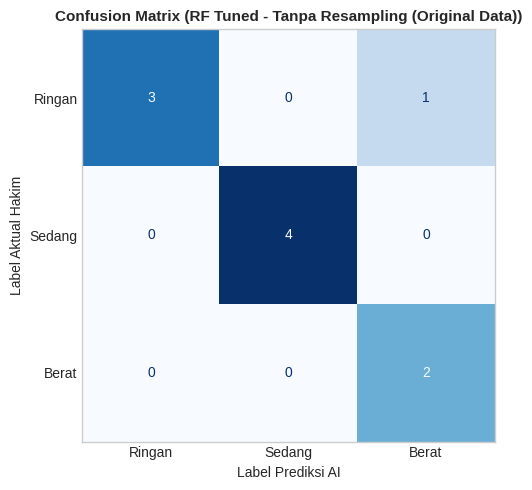

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification Report Detail untuk Model Terbaik
print(f"\n📋 LAPORAN KLASIFIKASI MODEL TERBAIK (RF TUNED - {best_sampler_name}):")
print("-" * 65)
y_pred_best = rf_best.predict(X_test)
target_names = ['Ringan (≤24 bln)', 'Sedang (25-48 bln)', 'Berat (>48 bln)']
print(classification_report(y_test, y_pred_best, target_names=target_names, digits=4))

# BARIS YANG DITAMBAHKAN: Menghitung confusion matrix
cm_best = confusion_matrix(y_test, y_pred_best)

# Visualisasi Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Ringan', 'Sedang', 'Berat'])
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)

ax.set_title(f"Confusion Matrix (RF Tuned - {best_sampler_name})", fontsize=11, fontweight='bold')
ax.set_xlabel('Label Prediksi AI', fontsize=10)
ax.set_ylabel('Label Aktual Hakim', fontsize=10)
ax.grid(False)

plt.tight_layout()
plt.show()


⏳ CELL 6: Menghitung SHAP Values menggunakan Model Terbaik (Tanpa Resampling (Original Data))...

📊 ANALISIS SHAP UNTUK KELAS: RINGAN (≤24 BLN)


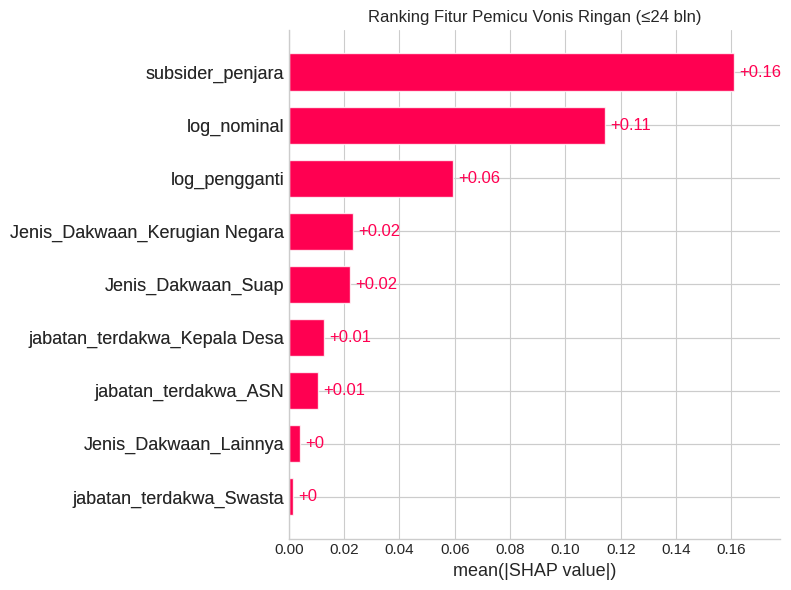

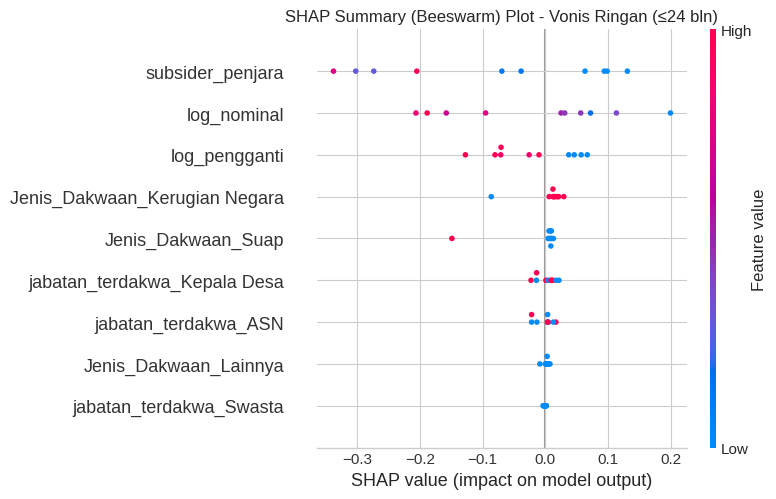


📊 ANALISIS SHAP UNTUK KELAS: SEDANG (25-48 BLN)


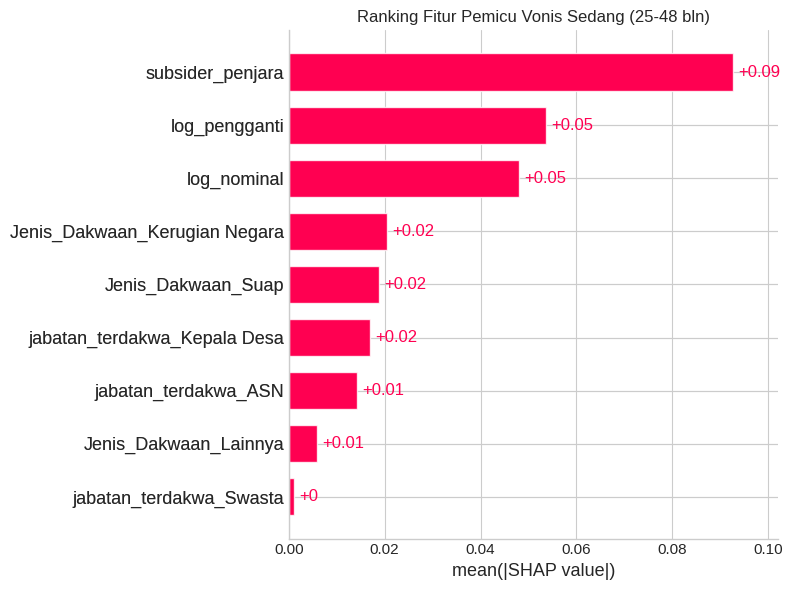

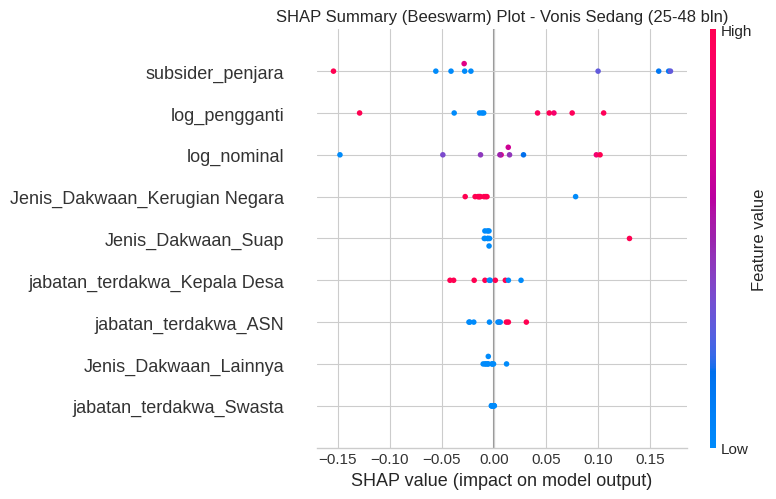


📊 ANALISIS SHAP UNTUK KELAS: BERAT (>48 BLN)


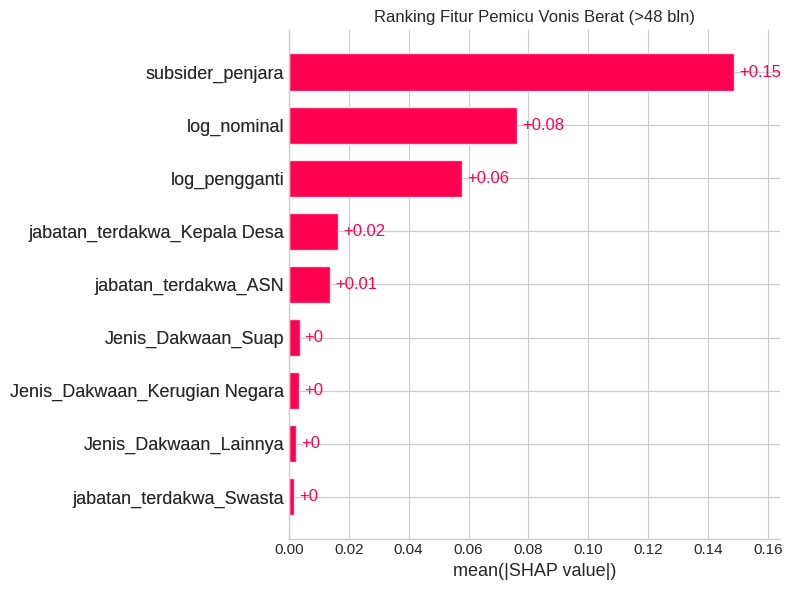

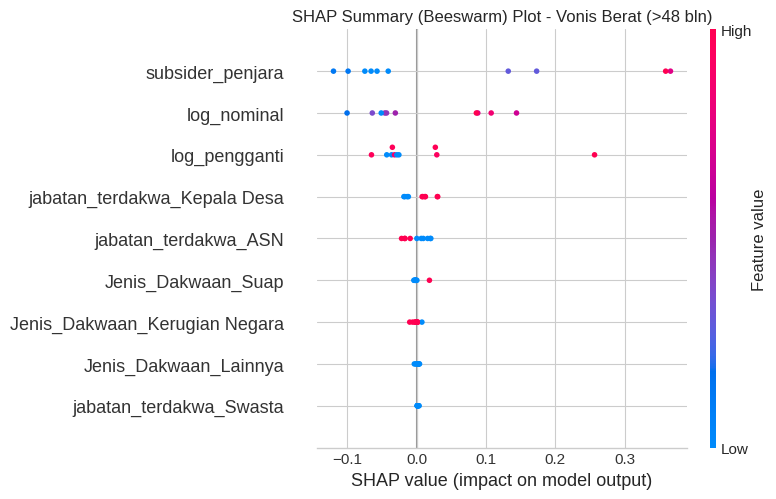


=== ANALISIS STUDI KASUS INDIVIDUAL (DATA TEST KE-0) ===
Vonis Asli Hakim : Ringan (≤24 bln)
Prediksi AI      : Berat (>48 bln)


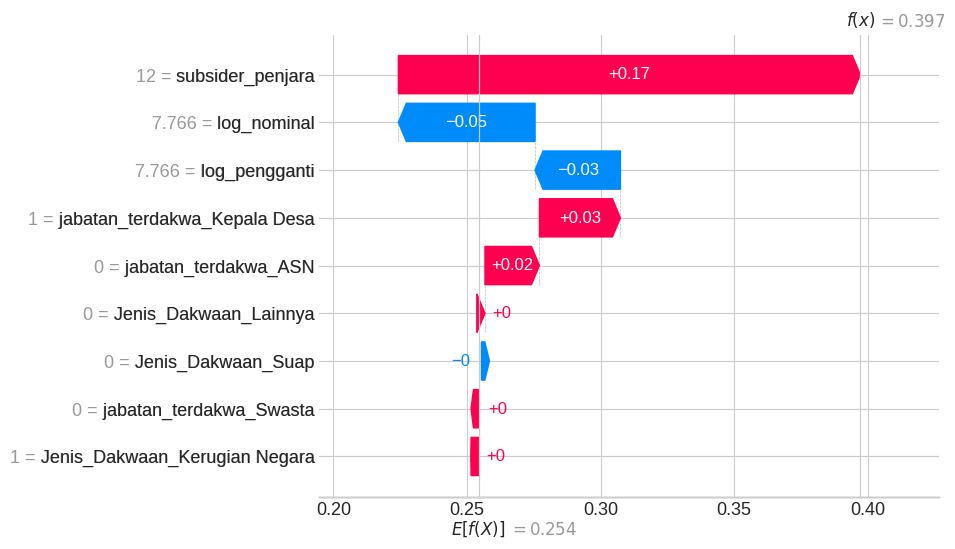

In [ ]:
# =========================================================================
# --- CELL 6: VISUALISASI SHAP EXPLAINER ---
# =========================================================================
print(f"\n⏳ CELL 6: Menghitung SHAP Values menggunakan Model Terbaik ({best_sampler_name})...")

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer(X_test)

label_dict = {0: 'Ringan (≤24 bln)', 1: 'Sedang (25-48 bln)', 2: 'Berat (>48 bln)'}

# Global Explanation per Kelas
for kelas_idx, nama_kelas in label_dict.items():
    print(f"\n======================================================")
    print(f"📊 ANALISIS SHAP UNTUK KELAS: {nama_kelas.upper()}")
    print(f"======================================================")

    shap_values_kelas = shap_values[:, :, kelas_idx]

    plt.figure(figsize=(10, 4))
    plt.title(f"Ranking Fitur Pemicu Vonis {nama_kelas}")
    shap.plots.bar(shap_values_kelas, show=False)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.title(f"SHAP Summary (Beeswarm) Plot - Vonis {nama_kelas}")
    shap.summary_plot(shap_values_kelas.values, X_test, show=False)
    plt.tight_layout()
    plt.show()

# Local Explanation (Kasus Sampel Ke-0)
idx_kasus = 0
prediksi_label = rf_best.predict(X_test.iloc[[idx_kasus]])[0]
vonis_asli = y_test.iloc[idx_kasus] if hasattr(y_test, 'iloc') else y_test[idx_kasus]

print(f"\n======================================================")
print(f"=== ANALISIS STUDI KASUS INDIVIDUAL (DATA TEST KE-{idx_kasus}) ===")
print(f"======================================================")
print(f"Vonis Asli Hakim : {label_dict[vonis_asli]}")
print(f"Prediksi AI      : {label_dict[prediksi_label]}")

# Penanganan Waterfall Plot dengan pengindeksan array langsung
shap.plots.waterfall(shap_values[idx_kasus, :, prediksi_label])

In [ ]:
# =========================================================================
# --- CELL 7: EVALUASI KENDALL'S TAU DAN SPEARMAN (RF TERBAIK VS HAKIM) ---
# =========================================================================
print("\n⏳ CELL 7: Menghitung Evaluasi Kendall's Tau & Spearman Correlation...")

# 1. EVALUASI KORELASI MODEL RF TERBAIK VS HAKIM
y_pred_best = rf_best.predict(X_test)

tau_best, p_tau_best = kendalltau(y_test, y_pred_best)
rho_best, p_rho_best = spearmanr(y_test, y_pred_best)

print(f"\n1️⃣ EVALUASI KORELASI MODEL RF TERBAIK ({best_sampler_name}) VS HAKIM:")
print("-" * 65)
print(f"• Kendall's Tau (tau)       : {tau_best:.4f} (p-value: {p_tau_best:.4e})")
print(f"• Spearman Correlation (rho) : {rho_best:.4f} (p-value: {p_rho_best:.4e})")

# 2. TABEL KORELASI FITUR DETERMINAN VS TARGET VONIS (SELURUH DATA)
fitur_numerik = ['subsider_penjara', 'log_nominal', 'log_pengganti']
corr_summary = []

for col in fitur_numerik:
    if col in X.columns:
        tau_f, p_tau_f = kendalltau(X[col], y)
        rho_f, p_rho_f = spearmanr(X[col], y)

        corr_summary.append({
            'Fitur Determinan': col,
            "Kendall's Tau (tau)": f"{tau_f:.4f}",
            'p-value (Tau)': f"{p_tau_f:.4e}",
            'Spearman (rho)': f"{rho_f:.4f}",
            'p-value (Spearman)': f"{p_rho_f:.4e}"
        })

df_corr_summary = pd.DataFrame(corr_summary)
print("\n📊 TABEL KORELASI FITUR DETERMINAN TERHADAP TARGET VONIS (SELURUH DATA):")
print("=" * 80)
print(df_corr_summary.to_string(index=False))
print("=" * 80)


⏳ CELL 7: Menghitung Evaluasi Kendall's Tau & Spearman Correlation...

1️⃣ EVALUASI KORELASI MODEL RF TERBAIK (Tanpa Resampling (Original Data)) VS HAKIM:
-----------------------------------------------------------------
• Kendall's Tau (tau)       : 0.6770 (p-value: 2.3555e-02)
• Spearman Correlation (rho) : 0.6736 (p-value: 3.2738e-02)

📊 TABEL KORELASI FITUR DETERMINAN TERHADAP TARGET VONIS (SELURUH DATA):
Fitur Determinan Kendall's Tau (tau) p-value (Tau) Spearman (rho) p-value (Spearman)
subsider_penjara              0.4522    2.9785e-07         0.4995         2.2155e-07
     log_nominal              0.2969    2.0244e-04         0.3815         1.2566e-04
   log_pengganti              0.3856    7.0814e-06         0.4445         5.7109e-06
